In [1]:
import pandas as pd

FILE = '/Volumes/PHD/phd/data/selected/above_value_minus1/all_no_embeddings.parquet'

In [2]:
import polars as pl

df = pl.read_parquet(FILE, columns=['uid', 'score'])
df.head()

uid,score
str,f64
"""c7f53e46e75b795a093c64d111fc07…",0.0
"""382a321a65932eab1401746dc7c45e…",0.0
"""0f6db3f46ae27620ce108fce5d1c6e…",0.0
"""7bf17fbb5850ad4d1b5399fdcb254e…",0.0
"""ca485850a0aa8c2ee981db79ffb430…",0.0


In [3]:
pd.set_option('display.float_format', '{:.2f}'.format)

df['score'].describe([0.01, 0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])

statistic,value
str,f64
"""count""",5.4910158e7
"""null_count""",0.0
"""mean""",0.077641
"""std""",0.597773
"""min""",-1.0
…,…
"""75%""",0.0
"""90%""",0.0
"""95%""",1.0


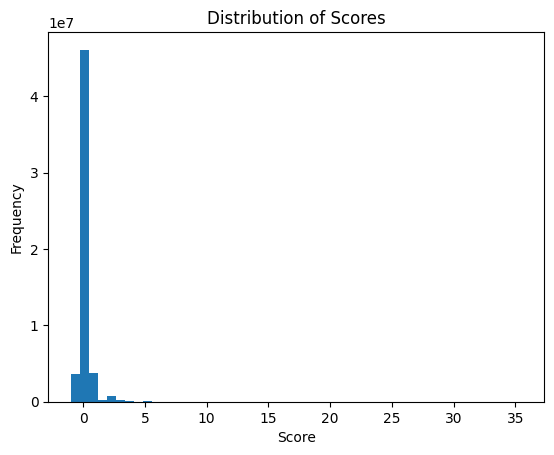

In [4]:
import matplotlib.pyplot as plt
plt.hist(df['score'], bins=50)
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of Scores')
plt.show()

In [5]:
import polars as pl

df = df.with_columns(
    pl.when(pl.col("score") == -1)
        .then(pl.lit('-1'))
      .when(pl.col("score") == -0.5)
        .then(pl.lit('-0.5'))
      .when((pl.col("score") == 0))
        .then(pl.lit('0'))
      .when((pl.col("score") == 0.5))
        .then(pl.lit('0.5'))
      .when((pl.col("score") == 1))
        .then(pl.lit('1'))
      .when((pl.col("score") > 1) & (pl.col("score") <= 2))
        .then(pl.lit('1 to 2'))
    .when((pl.col("score") > 2) & (pl.col("score") <= 5))
        .then(pl.lit('2 to 5'))
    .when((pl.col("score") > 5) & (pl.col("score") <= 10))
        .then(pl.lit('5 to 10'))
      .otherwise(pl.lit('10+'))
      .alias("score_category")
)

score_counts = (
    df.group_by("score_category")
      .count().sort("score_category")
)

score_percentages = score_counts.with_columns(
    (pl.col("count") / pl.col("count").sum() * 100).alias("percent")
)

print(score_counts)
print(score_percentages)


/var/folders/vw/8y99f8gn61ddx6t8ck0zm6ch0000gn/T/ipykernel_71296/2053185940.py:26: DeprecationWarning: `GroupBy.count` was renamed; use `GroupBy.len` instead
  .count().sort("score_category")


shape: (9, 2)
┌────────────────┬──────────┐
│ score_category ┆ count    │
│ ---            ┆ ---      │
│ str            ┆ u32      │
╞════════════════╪══════════╡
│ -0.5           ┆ 1535021  │
│ -1             ┆ 2116799  │
│ 0              ┆ 46092073 │
│ 0.5            ┆ 1161990  │
│ 1              ┆ 2576774  │
│ 1 to 2         ┆ 865202   │
│ 10+            ┆ 5468     │
│ 2 to 5         ┆ 473614   │
│ 5 to 10        ┆ 83217    │
└────────────────┴──────────┘
shape: (9, 3)
┌────────────────┬──────────┬───────────┐
│ score_category ┆ count    ┆ percent   │
│ ---            ┆ ---      ┆ ---       │
│ str            ┆ u32      ┆ f64       │
╞════════════════╪══════════╪═══════════╡
│ -0.5           ┆ 1535021  ┆ 2.795514  │
│ -1             ┆ 2116799  ┆ 3.855023  │
│ 0              ┆ 46092073 ┆ 83.940886 │
│ 0.5            ┆ 1161990  ┆ 2.116166  │
│ 1              ┆ 2576774  ┆ 4.692709  │
│ 1 to 2         ┆ 865202   ┆ 1.575668  │
│ 10+            ┆ 5468     ┆ 0.009958  │
│ 2 to 5         ┆

# Sampling

| bin_label | score range | komentarz            |
| --------- | ----------- | -------------------- |
| bin_1     | -1 to -0.5  | bardzo niskie        |
| bin_2     | -0.5 to 0   | niskie               |
| bin_3     | 0           | dominująca masa      |
| bin_4     | 0 to 0.5    | małe dodatnie        |
| bin_5     | 0.5 to 1    | średnie dodatnie     |
| bin_6     | 1 to 2      | umiarkowane dodatnie |
| bin_7     | 2 to 5      | wysokie dodatnie     |
| bin_8     | 5 to 10     | bardzo wysokie       |
| bin_9     | 10+         | ekstremalne wartości |

### Strategia minimalnej liczebności
- Minimalnie 500 próbek dla najmniejszych binów (bin_8, bin_9)
- Pozostałe biny uzupełniamy proporcjonalnie do liczebności w zbiorze
- Łącznie: 200k próbek

| bin   | percent w zbiorze | minimal | liczba próbek w 200k |
| ----- | ----------------- | ------- | -------------------- |
| bin_1 | 3%                | 500     | 6,000                |
| bin_2 | 2.8%              | 500     | 5,500                |
| bin_3 | 84%               | 500     | 168,000              |
| bin_4 | 2.1%              | 500     | 4,200                |
| bin_5 | 4.7%              | 500     | 9,400                |
| bin_6 | 1.6%              | 500     | 3,200                |
| bin_7 | 0.86%             | 500     | 1,720                |
| bin_8 | 0.15%             | 500     | 500 (min)            |
| bin_9 | 0.01%             | 500     | 500 (min)            |


In [7]:
import polars as pl
import numpy as np

df = pl.read_parquet(FILE)

In [11]:
bins = [-1, -0.5, 0, 0.5, 1, 2, 5, 10, np.inf]
labels = ["bin_1","bin_2","bin_3","bin_4","bin_5","bin_6","bin_7","bin_8","bin_9"]

def assign_bin(score):
    for i in range(len(bins)-1):
        if bins[i] < score <= bins[i+1]:
            return labels[i]
    return labels[-1]

df = df.with_columns([
    pl.col("score").map_elements(assign_bin).alias("score_bin")
])
print(df)

shape: (54_910_158, 6)
┌────────────────────────────┬───────────────────────────┬───────┬──────────┬──────────┬───────────┐
│ uid                        ┆ url                       ┆ score ┆ pos_keys ┆ neg_keys ┆ score_bin │
│ ---                        ┆ ---                       ┆ ---   ┆ ---      ┆ ---      ┆ ---       │
│ str                        ┆ str                       ┆ f64   ┆ str      ┆ str      ┆ str       │
╞════════════════════════════╪═══════════════════════════╪═══════╪══════════╪══════════╪═══════════╡
│ c7f53e46e75b795a093c64d111 ┆ http://abc-kaigishitsu.co ┆ 0.0   ┆          ┆          ┆ bin_2     │
│ fc07…                      ┆ m/osa…                    ┆       ┆          ┆          ┆           │
│ 382a321a65932eab1401746dc7 ┆ https://cdn.pistik.net/po ┆ 0.0   ┆          ┆          ┆ bin_2     │
│ c45e…                      ┆ rtaal…                    ┆       ┆          ┆          ┆           │
│ 0f6db3f46ae27620ce108fce5d ┆ http://ae01.alicdn.com/kf ┆ 0.0   ┆  

In [12]:
target_total = 200_000
samples = []

min_samples = {
    "bin_1": 500, "bin_2": 500, "bin_3": 500, "bin_4": 500,
    "bin_5": 500, "bin_6": 500, "bin_7": 500, "bin_8": 500, "bin_9": 500
}

for bin_label, min_n in min_samples.items():
    bin_df = df.filter(pl.col("score_bin") == bin_label)
    n_samples = min(len(bin_df), min_n)
    samples.append(bin_df.sample(n=n_samples, seed=42))

In [13]:
sampled_df = pl.concat(samples)

In [14]:
remaining = target_total - sampled_df.height
if remaining > 0:
    remaining_df = df.filter(~pl.col("uid").is_in(sampled_df["uid"]))
    sampled_df = pl.concat([sampled_df, remaining_df.sample(n=remaining, seed=42)])

/var/folders/vw/8y99f8gn61ddx6t8ck0zm6ch0000gn/T/ipykernel_71296/1587225771.py:3: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  remaining_df = df.filter(~pl.col("uid").is_in(sampled_df["uid"]))


In [15]:
sampled_df.write_parquet("../data_all/above_value_minus1/sample_200k.parquet")
print("200k próbek zapisane, wymiary:", sampled_df.shape)

200k próbek zapisane, wymiary: (200000, 6)


In [1]:
import polars as pl
sampled_df = pl.read_parquet("../data_all/above_value_minus1/sample_200k.parquet")

In [2]:
sampled_uids = set(sampled_df["uid"].to_list())

In [3]:
len(sampled_uids)

200000

In [5]:
from pathlib import Path

data_dir = Path("/Volumes/PHD/phd/data/selected/above_value_minus1/")
parquet_files = list(data_dir.glob("part*.parquet"))

# sampled_df z uid (zakładam, że już masz w Polars)
sampled_uids = sampled_df.select("uid").to_series().to_list()
sampled_uids_set = set(sampled_uids)

In [6]:
output_file = "../data_all/above_value_minus1/sample_200k_with_embeddings.parquet"

In [ ]:
for i, file in enumerate(parquet_files):
    print(f"Processing {file} ...")
    df = (
        pl.scan_parquet(file)
        .filter(pl.col("uid").is_in(sampled_uids))
        .select(["uid", "l14_img"])
        .collect()
    )

    if i == 0:
        df.write_parquet(output_file)
    else:
        df.write_parquet(output_file, append=True)

Processing /Volumes/PHD/phd/data/selected/above_value_minus1/part_0.parquet ...


In [9]:
all_l14_lazy = pl.concat(lazy_frames)

In [ ]:
result = sampled_df.lazy().join(all_l14_lazy, on="uid", how="left").collect()

In [ ]:
sampled_df.write_parquet("../data_all/above_value_minus1/sample_200k_with_embeddings.parquet")
print("200k próbek zapisane, wymiary:", sampled_df.shape)